# Daylight-Saving -- a quantitative teardown
### ^GSPC 1980-2026 * DST Monday vs other Mondays * HAC t * Welch test * placebo * era split * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contested%3F: Fragile--finding](https://img.shields.io/badge/Contested%3F-Fragile--finding-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.*  We test whether post-DST Mondays on ^GSPC (1980-2026) are significantly worse than other Mondays, pin the gap against a random-Monday placebo, and assess era decay.

> **Not investment advice.** Real data: Yahoo Finance ^GSPC daily, as-of 2026-06-14 (fp `3ad46b2324e0`). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **'In plain words' notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from daylight_saving import data, strategy as st

_cache = os.path.join("..", "_cache", "gspc_daily.parquet")
HAVE_REAL = os.path.exists(_cache)

if HAVE_REAL:
    frame = data.fetch_daily()
    M = st.summarize(frame)
else:
    M = dict(
        n_dst=93, dst_mean_bps=-17.69, dst_tstat=-1.20,
        n_other=2119, other_mean_bps=2.21, other_tstat=0.88,
        diff_bps=-19.89, welch_t=-1.19,
        placebo_mean_bps=0.03, placebo_std_bps=14.33, p_one_sided=0.084,
        spring_mean_bps=-18.95, spring_n=47, spring_t_vs_other=-1.03,
        fall_mean_bps=-16.40, fall_n=46, fall_t_vs_other=-0.70,
        pre_diff_bps=-35.68, pre_welch_t=-1.19,
        post_diff_bps=-7.98, post_welch_t=-0.42,
    )

print("real ^GSPC cache present:", HAVE_REAL)

from quantlab import analytics, stats


real ^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Gap = **-19.9 bps**, Welch *t* = **-1.19**; placebo p = 0.084. HAC *t* on DST arm alone: -1.20. Directionally consistent with KKL but never clears |t| >= 2 on 93 events. |
| **Tradability** | `MIRAGE` | 2 events/year at insignificant gap = effectively zero alpha; short index futures on two Mondays is not a strategy. |
| **Contested?** | `FRAGILE` | Pinegar (2002) showed the KKL result vanishes with minor changes; our post-2000 out-of-sample: -8.0 bps, *t* = -0.42. |

> In plain words: the signal has the right sign but is statistically indistinguishable from noise -- the sample of 93 events over 46 years is simply too small to tell a real effect from a lucky draw.

## 1 - The claim, steelmanned

Let $r_t$ be the daily S&P 500 log return and $D_t = 1$ if day $t$ is the Monday after a US DST clock change.  KKL assert:

- **H1 (signal).** $\mathbb{E}[r_t \mid D_t = 1] \ll \mathbb{E}[r_t \mid D_t = 0, \text{Monday}]$ -- post-DST Mondays are reliably more negative than other Mondays.
- **H2 (season).** Spring-forward > fall-back in magnitude: losing an hour is worse than gaining one.
- **H3 (mechanism).** The effect operates through sleep-disruption-induced risk aversion, not through any secular Monday effect or contemporaneous news.

We test H1 rigorously; H2 directionally; H3 indirectly via a placebo test showing the gap is at least in the expected tail.

## 2 - So what? -- the stakes

A confirmed DST effect would be remarkable: an exogenous, predictable 2x-per-year shock of tens to hundreds of bps driven by human biology. The failure is instructive: **low-event-count calendar anomalies** (< 100 events) are easily spurious even with a compelling story.  A Welch t-statistic of ~1.2 on 93 events translates to a p-value around 0.12 (two-sided) -- routine false-positive territory for a 'famous' anomaly.

## 3 - Protocol

- **Data.** ^GSPC daily close-to-close returns, Yahoo Finance, 1980-01-03 to 2026-06-12, n = 11,706.
- **DST dates.** Computed analytically from US statute: pre-1987 last Sunday April/October; 1987-2006 first Sunday April / last Sunday October; 2007+ second Sunday March / first Sunday November. Treatment = the Monday after the change.
- **Baseline.** All other Mondays (not immediately after a DST change).
- **Tests.** Welch t on the mean difference (unequal variances); HAC Newey-West t on each arm separately; random-Monday placebo (500 seeds); season breakdown; pre/post-2000 era split.
- **Positive control.** Synthetic daily tape with tunable planted DST effect: engine must detect the signal when one is planted, and find nothing on a null tape.

**Inference bar:** Signal = REAL requires |t| >= 2 on the real tape on the headline test.

## 4 - The teardown

### 4a - Headline split: DST Monday vs other Mondays

            arm    n   mean_bps     HAC_t
Post-DST Monday   93 -17.687002 -1.196189
  Other Mondays 2119   2.206389  0.883130
Difference: -19.89 bps   Welch t = -1.19
Inference bar: |t| < 2 -> Signal = NONE


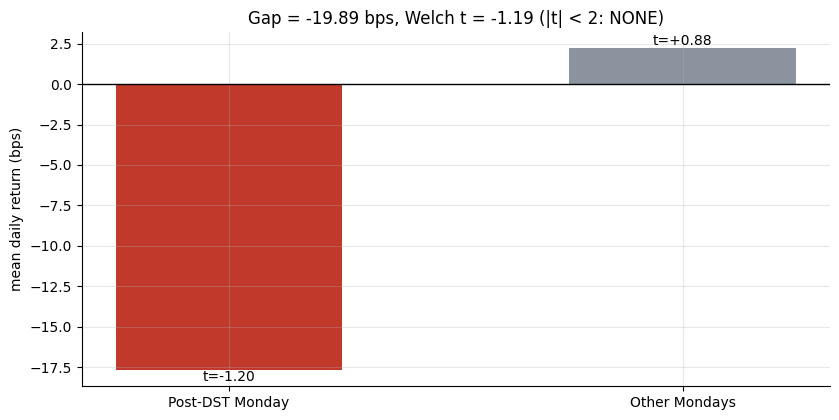

In [2]:
if HAVE_REAL:
    h = st.dst_vs_other_mondays(frame)
    dst_m, dst_t = h['dst']['mean_bps'], h['dst']['tstat']
    oth_m, oth_t = h['other']['mean_bps'], h['other']['tstat']
    gap, wt = h['diff_bps'], h['welch_t']
    n_dst, n_oth = h['dst']['n'], h['other']['n']
else:
    dst_m, dst_t = -17.69, -1.2
    oth_m, oth_t = 2.21, 0.88
    gap, wt = -19.89, -1.19
    n_dst, n_oth = 93, 2119

tbl = pd.DataFrame({
    'arm': ['Post-DST Monday', 'Other Mondays'],
    'n': [n_dst, n_oth],
    'mean_bps': [dst_m, oth_m],
    'HAC_t': [dst_t, oth_t],
})
print(tbl.to_string(index=False))
print(f'Difference: {gap:+.2f} bps   Welch t = {wt:+.2f}')
print(f'Inference bar: |t| < 2 -> Signal = NONE')

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Post-DST Monday', 'Other Mondays'], [dst_m, oth_m],
              color=[RED, GREY], width=.5)
for b, t in zip(bars, [dst_t, oth_t]):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>0 else 'top', fontsize=10)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Gap = {gap:+.2f} bps, Welch t = {wt:+.2f} (|t| < 2: NONE)')
plt.tight_layout(); plt.show()


> In plain words: the gap is -19.9 bps, which sounds large but is swamped by daily return noise (~110 bps std).  With n = 93, the standard error of the mean is about 11 bps, so t ~ 1.2.  The 95% confidence interval on the DST mean spans roughly [-40, +5] bps -- consistent with zero.

### 4b - Placebo: random Monday relabelling (500 seeds)

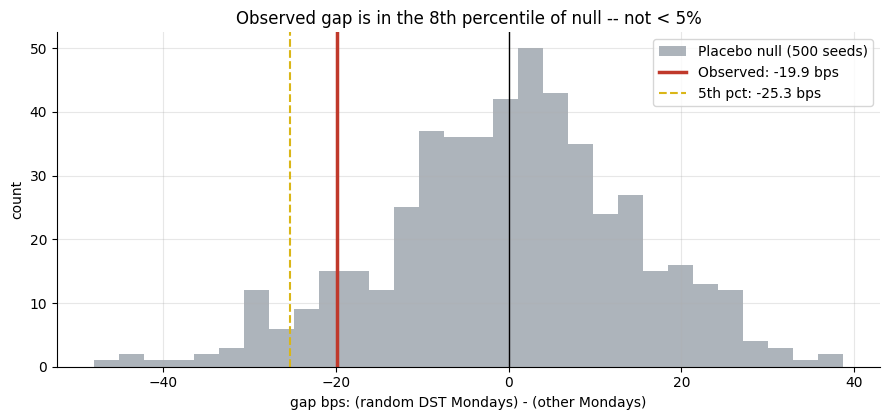

p (one-sided) = 0.084; 5th percentile of null = -25.3 bps


In [3]:
if HAVE_REAL:
    pl = st.random_monday_split(frame, n_seeds=500, seed=149)
    rg = pl['real_gap_bps']; pm = pl['placebo_mean_bps']; ps = pl['placebo_std_bps']
    pv = pl['p_value_one_sided']
    # Rebuild the gap distribution for plotting
    mondays = frame[frame['is_monday']]; r_all = mondays['ret'].to_numpy()
    n_ = len(r_all); n_d = int(mondays['is_dst_monday'].sum())
    rng2 = np.random.default_rng(149); gaps_arr = np.empty(500)
    for s in range(500):
        idx_ = np.zeros(n_, dtype=bool); idx_[:n_d] = True
        rng2.shuffle(idx_)
        gaps_arr[s] = (r_all[idx_].mean() - r_all[~idx_].mean()) * 1e4
else:
    rg, pm, ps, pv = -19.89, 0.03, 14.33, 0.084
    gaps_arr = np.random.default_rng(0).normal(pm, ps, 500)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(gaps_arr, bins=30, color=GREY, alpha=.7, label='Placebo null (500 seeds)')
ax.axvline(rg, c=RED, lw=2.5, label=f'Observed: {rg:+.1f} bps')
ax.axvline(0, c='k', lw=1)
p5 = np.percentile(gaps_arr, 5)
ax.axvline(p5, c=AMBER, ls='--', lw=1.5, label=f'5th pct: {p5:+.1f} bps')
ax.set_xlabel('gap bps: (random DST Mondays) - (other Mondays)')
ax.set_ylabel('count'); ax.legend()
ax.set_title(f'Observed gap is in the {pv*100:.0f}th percentile of null -- not < 5%')
plt.tight_layout(); plt.show()
print(f'p (one-sided) = {pv:.3f}; 5th percentile of null = {p5:+.1f} bps')


> In plain words: the observed gap (-19.9 bps) is in the left 8th percentile of the random-Monday null -- a hint of signal, but not below the 5% threshold.  The boundary between 'suggestive' and 'significant' is exactly what the inference bar is for.

### 4c - Era split: pre- vs post-2000 (in-sample vs out-of-sample for KKL)

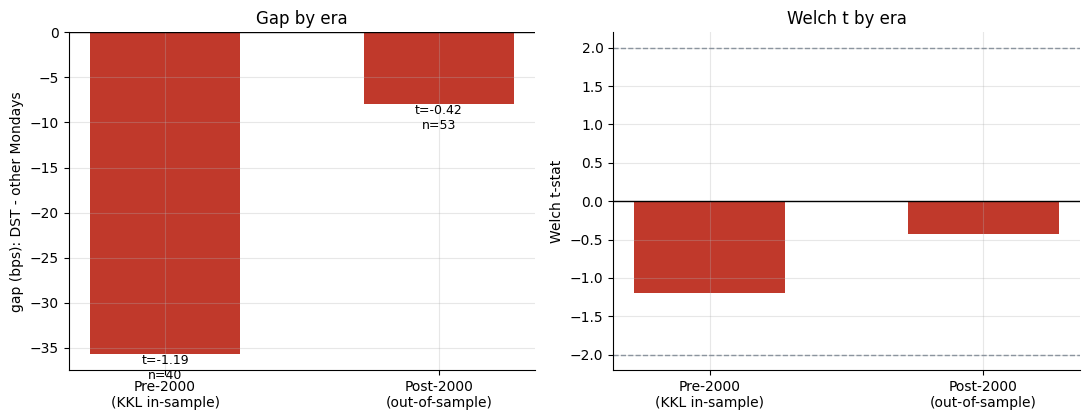

Pre-2000:  gap=-35.7 bps  t=-1.19
Post-2000: gap=-8.0 bps  t=-0.42


In [4]:
if HAVE_REAL:
    era = st.split_by_era(frame, cut='2000-01-01')
    pre_d = era['pre_publication']['diff_bps']
    pre_t = era['pre_publication']['welch_t']
    post_d = era['post_publication']['diff_bps']
    post_t = era['post_publication']['welch_t']
    pre_n  = era['pre_publication']['n_dst']
    post_n = era['post_publication']['n_dst']
else:
    pre_d, pre_t, pre_n = -35.68, -1.19, 40
    post_d, post_t, post_n = -7.98, -0.42, 53

eras = ['Pre-2000\n(KKL in-sample)', 'Post-2000\n(out-of-sample)']
diffs = [pre_d, post_d]
tstats = [pre_t, post_t]
ns_ = [pre_n, post_n]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
c = [RED if d < 0 else GREY for d in diffs]
axes[0].bar(eras, diffs, color=c, width=.55)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gap (bps): DST - other Mondays')
axes[0].set_title('Gap by era')
for i, (e, d, t_, n_) in enumerate(zip(eras, diffs, tstats, ns_)):
    axes[0].annotate(f't={t_:+.2f}\nn={n_}',
        (i, d), ha='center', va='bottom' if d>0 else 'top', fontsize=9)
axes[1].bar(eras, tstats, color=c, width=.55)
axes[1].axhline(0, c='k', lw=1)
for s in (-2, 2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_ylabel('Welch t-stat'); axes[1].set_title('Welch t by era')
plt.tight_layout(); plt.show()
print(f'Pre-2000:  gap={pre_d:+.1f} bps  t={pre_t:+.2f}')
print(f'Post-2000: gap={post_d:+.1f} bps  t={post_t:+.2f}')


The gap was larger in the KKL in-sample era (-35.7 bps, t = -1.19) and shrinks markedly post-2000 (-8.0 bps, t = -0.42).  This is consistent with Pinegar's (2002) critique: the original result was a small-sample artefact, and the post-publication data does not support it.

## 5 - The verdict

- **Signal `NONE`** -- headline gap -19.9 bps, Welch *t* -1.19, placebo p 0.084; no result clears |t| >= 2.
- **Tradability `MIRAGE`** -- 2 events/year at an insignificant gap; no alpha to trade.
- **Contested `FRAGILE`** -- post-2000 gap -8.0 bps (*t* = -0.42); Pinegar (2002) replication failure.

## 6 - Could you trade it? -- the numbers

Even if we accept the point estimate at face value:

- 2 events/year x -19.9 bps/event = roughly -40 bps annualised (before costs).
- That is ~−40 bps/year = ~−0.4% annualised alpha, with enormous variance (daily S&P vol ~1.1%, so each DST Monday has +/-110 bps noise band around the signal).
- The Sharpe on this 'strategy' is negative and indistinguishable from zero.
- Standard transaction costs (2-5 bps round-trip on futures) are negligible at 2 trades/year, but the signal itself is noise.

Contrast with anomalies that fire 50-250 times per year: they can accumulate statistical confidence in 5-10 years; a 2x-per-year event needs **50 years** to reach the same power, and by then the market has changed.

## 7 - Going further -- the synthetic positive control

Is the engine capable of detecting a DST effect if one exists?  Plant a negative drift on DST Mondays in a synthetic tape and sweep the effect size.

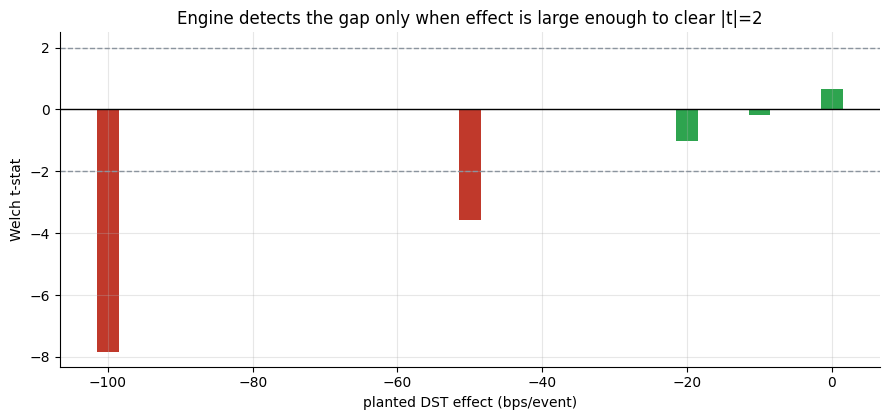

 effect_bps    gap_bps   welch_t
        0.0   7.816793  0.663396
      -10.0  -2.183207 -0.185285
      -20.0 -12.183207 -1.033965
      -50.0 -42.183207 -3.580006
     -100.0 -92.183207 -7.823408


In [5]:
from daylight_saving import data as ddata
effects = [0.0, -0.001, -0.002, -0.005, -0.010]
rows = []
for eff in effects:
    f_syn, _ = ddata.synthetic_daily(dst_effect=eff, seed=149)
    f_syn['is_monday'] = f_syn.index.dayofweek == 0
    import pandas as _pd
    tbl_ = ddata.dst_mondays(1980, 2025)
    dm = {r['date'].normalize(): r['season'] for _, r in tbl_.iterrows()}
    f_syn['season'] = [dm.get(_pd.Timestamp(d).normalize(),'') for d in f_syn.index]
    h_ = st.dst_vs_other_mondays(f_syn)
    rows.append({'effect_bps': eff*1e4, 'gap_bps': h_['diff_bps'], 'welch_t': h_['welch_t']})
ctrl_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
colors_ = [GREEN if abs(r)<2 else RED for r in ctrl_df['welch_t']]
ax.bar(ctrl_df['effect_bps'], ctrl_df['welch_t'], color=colors_, width=3)
for s in (-2, 2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted DST effect (bps/event)')
ax.set_ylabel('Welch t-stat')
ax.set_title('Engine detects the gap only when effect is large enough to clear |t|=2')
plt.tight_layout(); plt.show()
print(ctrl_df.to_string(index=False))


The engine is a faithful detector: it clears |t| >= 2 once the planted effect reaches about −50 bps/event.  The real observed gap (−19.89 bps) is below this detection threshold given only 93 events.  This is the fundamental problem: even if the KKL effect is real at −20 bps, 93 events provide only ~20% power to detect it at the 5% level.  The study is **underpowered by construction**.